# Base 02 — Metro Interstate Traffic Volume

## 1. Bibliotecas e configuração

Carregar as bibliotecas antes de definir o recorte e os caminhos de saída.

In [1]:
from pathlib import Path
from time import perf_counter
import json
import hashlib
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import sklearn, statsmodels
from threadpoolctl import threadpool_limits
_blas_limit = threadpool_limits(limits=1)

### 1.1 Parâmetros do experimento

Todos os modelos usam o mesmo horizonte, as mesmas datas e o mesmo `random_state` quando aplicável.

In [2]:
BASE_ID = 'base_02'
TARGET = 'traffic_volume'
DATETIME_COL = 'date_time'
RANDOM_STATE = 67
HORIZON = 1
FREQ = 'h'
TRAIN_RATIO = 0.80
TRAIN_WINDOW = 8 * 168   # mesmas oito semanas recentes para todos os modelos
REFIT_HOURS = 168       # coeficientes reestimados semanalmente
VALIDATION_HOURS = 168
N_FOLDS = 2
MODEL_NAMES = ['SVR', 'Decision Tree', 'Random Forest', 'SARIMAX', 'Holt-Winters']
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'data/raw/base_02').is_dir())
DATA_PATH = PROJECT_ROOT / 'data/raw/base_02/Metro_Interstate_Traffic_Volume_2016_2018_regularizada_sem_imputacao.csv'
RESULTS = PROJECT_ROOT / 'results'
for folder in ['metrics', 'predictions', 'residuals', 'feature_importance', 'tuning', 'analysis', 'figures/base_02']:
    (RESULTS / folder).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (13, 4), 'axes.grid': True, 'grid.alpha': .2})

def savefig(name):
    plt.tight_layout()
    plt.savefig(RESULTS / 'figures/base_02' / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()

print('Versões:', platform.python_version(), pd.__version__, sklearn.__version__, statsmodels.__version__)
print('SHA256 entrada:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())

Versões: 3.12.5 2.2.2 1.6.1 0.14.6
SHA256 entrada: 3c105848c040bbbcf3deb07da26a5ab3a1487543c342dc0501ba97c63679bca4


## 2. Carregar e auditar a base horária

Conferir frequência, duplicidades e preservação dos valores ausentes antes de qualquer ajuste.

In [3]:
raw = pd.read_csv(DATA_PATH, parse_dates=[DATETIME_COL]).sort_values(DATETIME_COL)
assert raw[DATETIME_COL].notna().all() and not raw[DATETIME_COL].duplicated().any()
df = raw.set_index(DATETIME_COL).asfreq(FREQ)
assert len(df) == len(raw), 'A entrada deveria estar regularizada.'
assert df.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
assert df[TARGET].dropna().ge(0).all()
if 'traffic_volume_original' in df:
    pd.testing.assert_series_equal(df[TARGET], df['traffic_volume_original'], check_names=False)

### 2.1 Dividir desenvolvimento e teste

O corte é cronológico e feito sobre a grade de horas. Os dois folds de validação ficam antes do teste final.

In [4]:
y = df[TARGET].astype(float)
split_pos = int(len(df) * TRAIN_RATIO)
TEST_START = df.index[split_pos]
folds = [(split_pos - (N_FOLDS - k) * VALIDATION_HOURS,
          split_pos - (N_FOLDS - k - 1) * VALIDATION_HOURS) for k in range(N_FOLDS)]
assert folds[0][0] > TRAIN_WINDOW + 168
display(pd.DataFrame([
    {'conjunto': 'Desenvolvimento', 'inicio': df.index[0], 'fim': df.index[split_pos-1],
     'horas': split_pos, 'alvos_observados': y.iloc[:split_pos].notna().sum()},
    {'conjunto': 'Teste final', 'inicio': TEST_START, 'fim': df.index[-1],
     'horas': len(df)-split_pos, 'alvos_observados': y.iloc[split_pos:].notna().sum()},
]))
display(pd.DataFrame([{'fold': i+1, 'treino_inicio': df.index[a-TRAIN_WINDOW],
    'treino_fim': df.index[a-1], 'validacao_inicio': df.index[a], 'validacao_fim': df.index[b-1]}
    for i, (a,b) in enumerate(folds)]))
display(df[['temp','rain_1h','snow_1h','clouds_all',TARGET]].isna().sum().to_frame('ausentes'))

,conjunto,inicio,fim,horas,alvos_observados
0,Desenvolvimento,2016-01-01 00:00:00,2018-03-14 03:00:00,19276,18279
1,Teste final,2018-03-14 04:00:00,2018-09-30 23:00:00,4820,4805


,fold,treino_inicio,treino_fim,validacao_inicio,validacao_fim
0,1,2018-01-03 04:00:00,2018-02-28 03:00:00,2018-02-28 04:00:00,2018-03-07 03:00:00
1,2,2018-01-10 04:00:00,2018-03-07 03:00:00,2018-03-07 04:00:00,2018-03-14 03:00:00


,ausentes
temp,1012
rain_1h,1012
snow_1h,1012
clouds_all,1012
traffic_volume,1012


## 3. Exploração da série

Os gráficos desta etapa usam apenas o período de desenvolvimento.

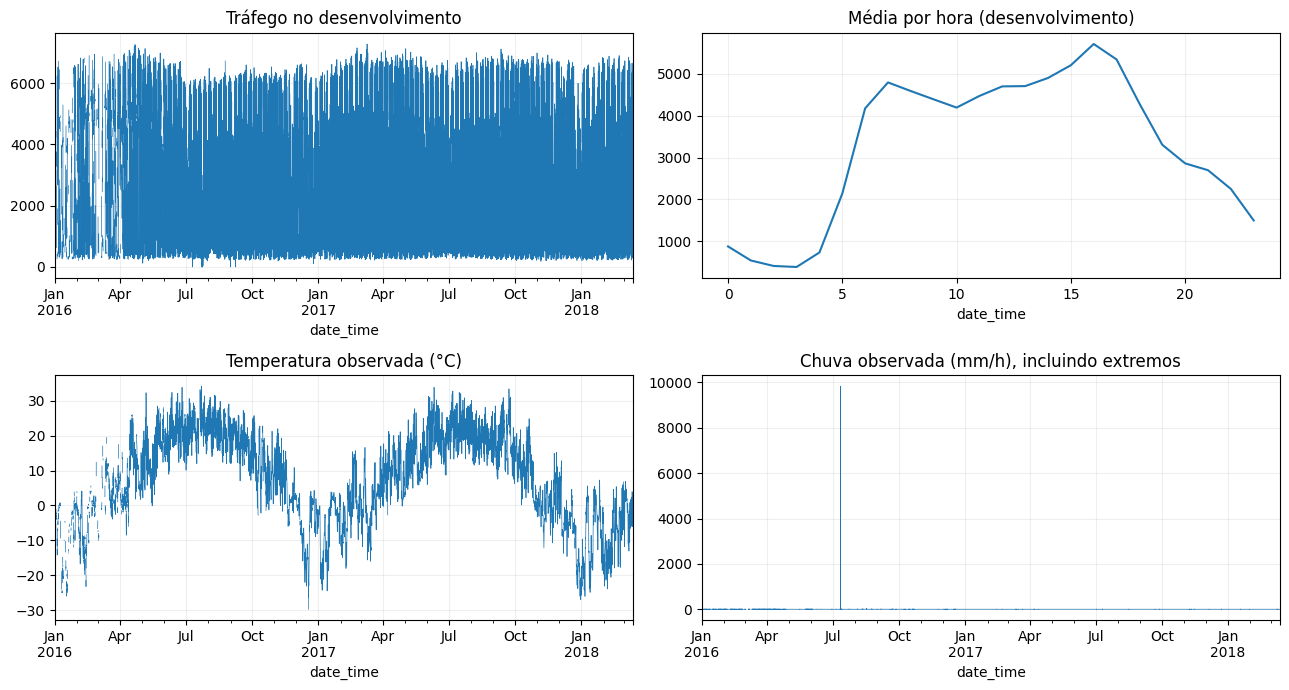

In [5]:
dev = df.iloc[:split_pos]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
dev[TARGET].plot(ax=axes[0,0], lw=.5, title='Tráfego no desenvolvimento')
dev.groupby(dev.index.hour)[TARGET].mean().plot(ax=axes[0,1], title='Média por hora (desenvolvimento)')
(dev['temp'] - 273.15).plot(ax=axes[1,0], lw=.5, title='Temperatura observada (°C)')
dev['rain_1h'].plot(ax=axes[1,1], lw=.5, title='Chuva observada (mm/h), incluindo extremos')
savefig('01_exploracao')

### 3.1 Decomposição STL do período de desenvolvimento

A STL usa somente desenvolvimento. Para viabilizar a decomposição, a cópia descritiva recebe `ffill`; a série real usada na avaliação permanece intacta. O componente STL nunca entra como feature, porque a decomposição pode usar observações dos dois lados de cada ponto. A força sazonal é `max(0, 1 - Var(resíduo)/Var(sazonal + resíduo))`. Os períodos 24 e 168 são avaliados separadamente, e suas forças não são aditivas.

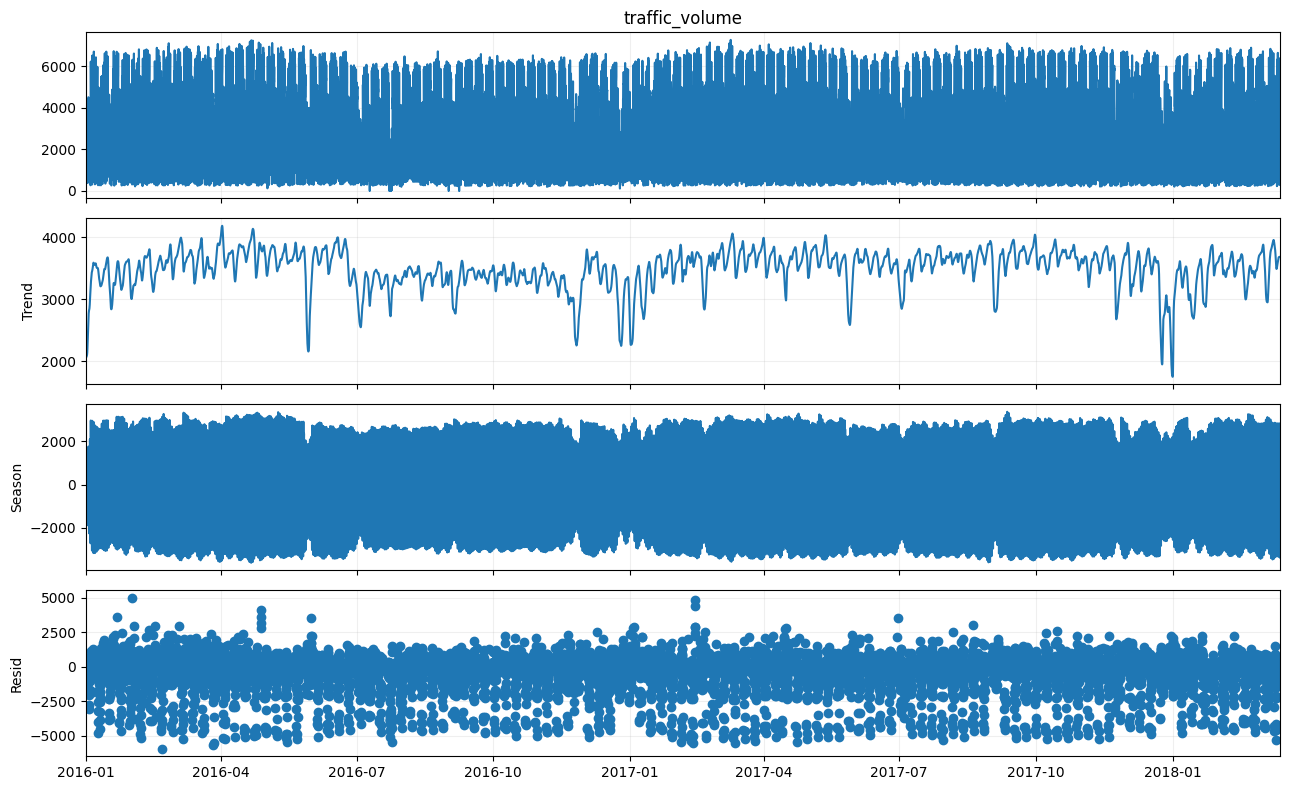

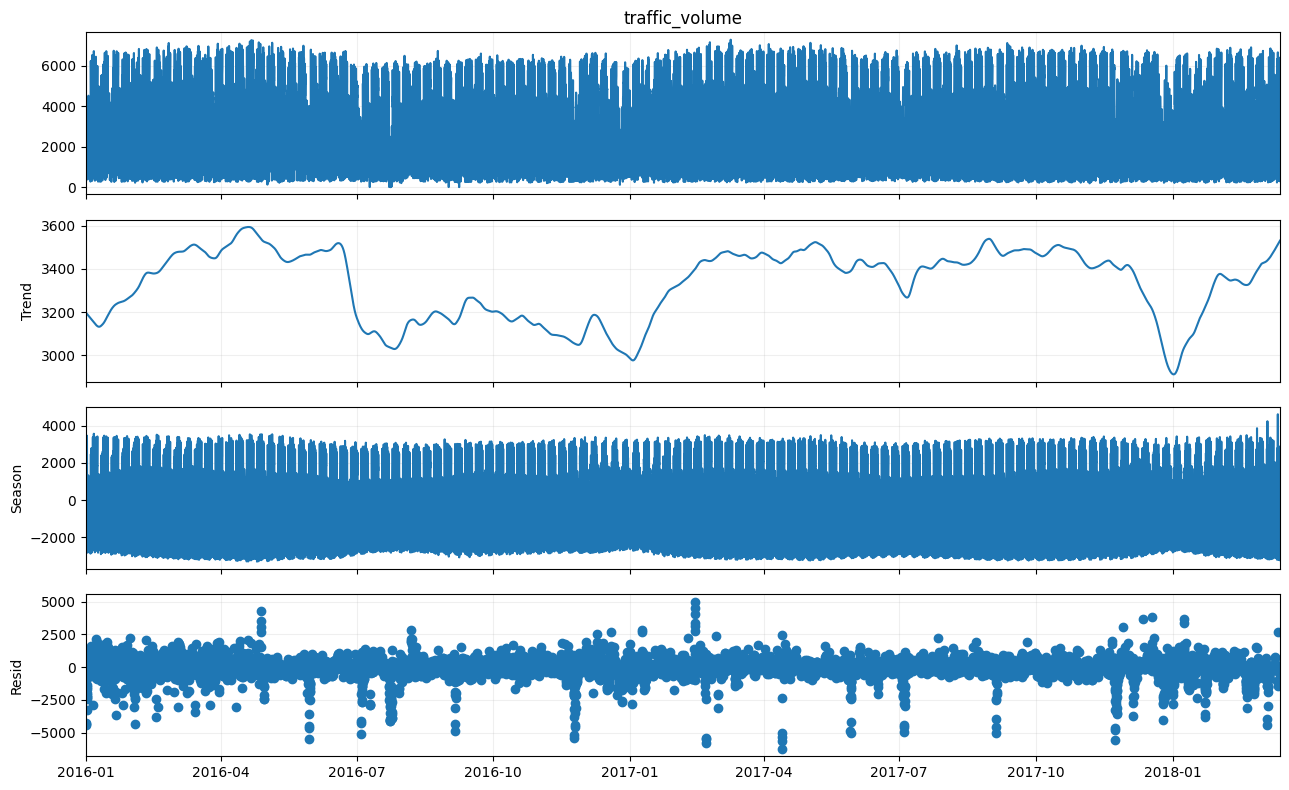

,periodo_horas,forca_sazonalidade
0,24,0.786814
1,168,0.942337


In [6]:
stl_rows = []
for period in [24, 168]:
    dec = STL(y.iloc[:split_pos].ffill().bfill(), period=period, robust=True).fit()
    strength = max(0., 1 - np.var(dec.resid) / np.var(dec.seasonal + dec.resid))
    stl_rows.append({'periodo_horas': period, 'forca_sazonalidade': strength})
    dec.plot()
    plt.gcf().set_size_inches(13, 8)
    savefig(f'02_stl_{period}')
stl_summary = pd.DataFrame(stl_rows)
display(stl_summary)

## 4. Feature engineering sem vazamento

Cada linha representa a hora prevista `t`. Como o horizonte é **uma hora** e cada previsão é emitida após observar `t-1`, `lag1` e as janelas encerradas em `t-1` são válidos. Para prever várias horas de uma vez, sem receber novos valores reais, seria preciso deslocar os lags e as janelas conforme o novo horizonte. As janelas permanecem em horas mesmo quando existem lacunas. Os valores ausentes das features recebem mediana aprendida apenas na janela de ajuste; as categorias e a padronização também são ajustadas nessa janela. SVR, Decision Tree e Random Forest usam as mesmas features.

Chuva e neve recebem `log1p` para reduzir a influência da escala e dos extremos. Isso não valida medições extremas nem autoriza sua remoção. O clima recebe `ffill` por no máximo seis horas, antes da defasagem, e indicadores registram indisponibilidade. Desvios de janelas sem observações suficientes ficam ausentes até a imputação de treino.

### 4.1 Definir calendário, clima defasado e histórico do alvo

A função constrói cada linha a partir do que estava disponível até a hora anterior.

In [7]:
def make_features(frame):
    t = frame.index
    X = pd.DataFrame(index=t)
    X['hora'] = t.hour
    X['dia_semana'] = t.dayofweek
    X['mes'] = t.month
    X['fim_de_semana'] = (t.dayofweek >= 5).astype(int)
    for name, values, cycle in [('hora', t.hour, 24), ('semana', t.dayofweek*24+t.hour, 168),
                                ('ano', t.dayofyear-1, 365.25)]:
        X[name+'_sin'] = np.sin(2*np.pi*values/cycle)
        X[name+'_cos'] = np.cos(2*np.pi*values/cycle)
    for col in ['temp','rain_1h','snow_1h','clouds_all']:
        s = frame[col].where(frame[col].ge(0)).ffill(limit=6).shift(1)
        X[col+'_lag1_ausente'] = s.isna().astype(int)
        X[col+'_lag1'] = np.log1p(s) if col in ['rain_1h','snow_1h'] else s
    X['weather_main_lag1'] = frame['weather_main'].ffill(limit=6).shift(1).fillna('Desconhecido')
    for lag in [1,2,3,6,12,24,48,168]:
        X[f'volume_lag{lag}'] = frame[TARGET].shift(lag)
        X[f'volume_lag{lag}_ausente'] = X[f'volume_lag{lag}'].isna().astype(int)
    past = frame[TARGET].shift(1)
    for window in [3,6,24,168]:
        roll = past.rolling(window, min_periods=max(2, window//4))
        X[f'media_{window}h'] = roll.mean()
        X[f'desvio_{window}h'] = roll.std()
        X[f'observacoes_{window}h'] = past.rolling(window, min_periods=1).count()
    X['variacao_1h'] = X.volume_lag1 - X.volume_lag2
    X['variacao_diaria'] = X.volume_lag1 - X.volume_lag24
    return X

### 4.2 Gerar e revisar as features

Conferir a causalidade e salvar a grade com seus ausentes preservados.

In [8]:
X = make_features(df)
CAT_COLS = ['weather_main_lag1']
NUM_COLS = [c for c in X if c not in CAT_COLS]
EXOG_COLS = ['hora_sin','hora_cos','semana_sin','semana_cos','fim_de_semana',
             'temp_lag1','rain_1h_lag1','snow_1h_lag1','clouds_all_lag1']
assert TARGET not in X and 'traffic_volume_original' not in X
# Alterar presente e futuro não pode alterar features anteriores ou da própria origem.
probe = df.copy()
cut = folds[0][0]
probe.loc[probe.index[cut]:, TARGET] = 999999.
probe.loc[probe.index[cut]:, ['temp','rain_1h','snow_1h','clouds_all']] = 999.
probe.loc[probe.index[cut]:, 'weather_main'] = 'FUTURO'
pd.testing.assert_frame_equal(X.iloc[:cut+1], make_features(probe).iloc[:cut+1])
print('Features:', X.shape[1], '| Teste de causalidade: passou')
display(X.iloc[168:173])
processed = pd.concat([y, X], axis=1)
(PROJECT_ROOT / 'data/processed').mkdir(parents=True, exist_ok=True)
processed.to_parquet(PROJECT_ROOT / 'data/processed/base_02.parquet')

Features: 49 | Teste de causalidade: passou


,hora,dia_semana,mes,fim_de_semana,hora_sin,hora_cos,semana_sin,semana_cos,ano_sin,ano_cos,...,desvio_6h,observacoes_6h,media_24h,desvio_24h,observacoes_24h,media_168h,desvio_168h,observacoes_168h,variacao_1h,variacao_diaria
date_time,,,,,,,,,,,,,,,,,,,,,
2016-01-08 00:00:00,0,4,1,0,0.000000,1.000000,-0.433884,-0.900969,0.120126,0.992759,...,1022.533292,3.0,3149.062500,2244.733792,16.0,2835.026087,1954.128811,115.0,NaN,683.0
2016-01-08 01:00:00,1,4,1,0,0.258819,0.965926,-0.467269,-0.884115,0.120126,0.992759,...,1223.471155,4.0,3153.437500,2239.409028,16.0,2827.330435,1961.110976,115.0,-613.0,305.0
2016-01-08 02:00:00,2,4,1,0,0.500000,0.866025,-0.500000,-0.866025,0.120126,0.992759,...,1144.797653,4.0,3155.687500,2236.391669,16.0,2816.973913,1971.035352,115.0,-269.0,44.0
2016-01-08 03:00:00,3,4,1,0,0.707107,0.707107,-0.532032,-0.846724,0.120126,0.992759,...,1144.797653,4.0,3345.066667,2178.043731,15.0,2816.973913,1971.035352,115.0,NaN,NaN
2016-01-08 04:00:00,4,4,1,0,0.866025,0.500000,-0.563320,-0.826239,0.120126,0.992759,...,406.709048,4.0,3336.866667,2189.624001,15.0,2814.208696,1974.224958,115.0,NaN,-680.0


## 5. Protocolo walk-forward e modelos

Em cada bloco semanal, ajustar usando as oito semanas anteriores à primeira previsão. Dentro do bloco, prever cada hora com histórico disponível até a hora anterior. Após observar a hora, atualizar os estados de SARIMAX e Holt-Winters e os lags dos modelos tabulares. As árvores e o SVR mantêm seus parâmetros dentro da semana. Na semana seguinte, todos são reajustados com a janela mais recente.

As features tabulares são calculadas em lote por conveniência, mas cada linha depende apenas do passado. SARIMAX usa previsões **one-step-ahead filtradas**, nunca suavizadas. Holt-Winters atualiza seus estados por recursão causal. Isso é avaliação sequencial com observações chegando a cada hora, não previsão de toda a semana feita de uma só vez.

**Lacunas:** SARIMAX trata `NaN` no filtro de estados. Holt-Winters requer uma série completa no ajuste: sua cópia recebe preenchimento para frente. Na atualização do teste, uma hora sem observação apenas avança o estado sem incorporar um alvo inventado. Árvores e SVR ajustam somente em linhas com alvo observado. Todos geram previsões para todas as horas, mas o MAE exclui as mesmas horas sem alvo.

**Modelos:** SVR com kernel RBF, imputação e padronização; Decision Tree e Random Forest com controle de profundidade e folhas; SARIMAX com exógenas defasadas e sazonalidade diária; Holt-Winters aditivo com sazonalidade diária ou semanal. A sazonalidade multiplicativa não é usada porque a série contém zeros. As configurações são selecionadas pelo MAE de validação. AIC/BIC e convergência são registrados para SARIMAX.

### 5.1 SVR, Decision Tree e Random Forest

Os três recebem as mesmas colunas. Imputação, escala e codificação são ajustadas em cada janela de treino.

In [9]:
def tabular_model(name, params):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
                        ('scale', StandardScaler())])
    prep = ColumnTransformer([
        ('num', numeric, NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)])
    if name == 'SVR':
        est = SVR(kernel='rbf', cache_size=512, **params)
    elif name == 'Decision Tree':
        est = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    else:
        est = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **params)
    return Pipeline([('prep', prep), ('model', est)])

def forecast_tabular(name, params, ytr, Xtr, Xfuture):
    model = tabular_model(name, params)
    mask = ytr.notna()
    model.fit(Xtr.loc[mask], ytr.loc[mask])
    pred = model.predict(Xfuture)
    return pred, model, {}

### 5.2 SARIMAX

Usar exógenas defasadas e atualizar o estado ao receber cada observação, com coeficientes fixos dentro do bloco.

In [10]:
def forecast_sarimax(params, ytr, yfuture, Xtr, Xfuture):
    prep = Pipeline([('fill', SimpleImputer(strategy='median', keep_empty_features=True)),
                     ('scale', StandardScaler())])
    ex_train = pd.DataFrame(prep.fit_transform(Xtr[EXOG_COLS]), index=ytr.index, columns=EXOG_COLS)
    ex_future = pd.DataFrame(prep.transform(Xfuture[EXOG_COLS]), index=yfuture.index, columns=EXOG_COLS)
    # Intercepto explícito evita conflito com exógenas constantes em blocos de uma hora.
    ex_train.insert(0, 'const', 1.)
    ex_future.insert(0, 'const', 1.)
    model = SARIMAX(ytr/1000., exog=ex_train, trend='n', **params,
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=100)
    # extend filtra em ordem: fittedvalues[t] usa apenas observações até t-1.
    pred = np.asarray(fit.extend(yfuture/1000., exog=ex_future).fittedvalues)*1000.
    details = {'aic': fit.aic, 'bic': fit.bic,
               'convergiu': bool(fit.mle_retvals.get('converged', False))}
    return pred, (fit, prep, ex_future), details

### 5.3 Holt-Winters

A função de atualização emite a previsão antes de incorporar o valor real daquela hora. A janela de oito semanas contém mais de dois ciclos das sazonalidades horárias testadas (24 e 168 horas).

In [11]:
def hw_online(fit, values):
    """Recursão aditiva, equivalente às equações do statsmodels, com NaN causal."""
    p = fit.params
    alpha, gamma = p['smoothing_level'], p['smoothing_seasonal']
    has_trend = fit.model.has_trend
    beta = p['smoothing_trend'] if has_trend else 0.
    phi = p['damping_trend'] if fit.model.damped_trend else 1.
    level = float(fit.level.iloc[-1])
    trend = float(fit.trend.iloc[-1]) if has_trend else 0.
    season = np.asarray(fit.season[-fit.model.seasonal_periods:], dtype=float).copy()
    forecasts = []
    for i, actual in enumerate(values):
        j = i % len(season)
        base = level + phi*trend
        forecasts.append(base + season[j])  # emitir antes de observar actual
        if np.isfinite(actual):
            new_level = alpha*(actual-season[j]) + (1-alpha)*base
            new_trend = beta*(new_level-level) + (1-beta)*phi*trend if has_trend else 0.
            season[j] = gamma*(actual-base) + (1-gamma)*season[j]
            level, trend = new_level, new_trend
        else:
            level, trend = base, phi*trend
    return np.asarray(forecasts)

In [12]:
def forecast_holt_winters(params, start, first_train_hour, yfuture):
    # ffill é feito sobre o prefixo; preserva informação anterior à janela.
    filled = y.iloc[:start].ffill().iloc[first_train_hour:start]
    assert filled.notna().all()
    trend = params['trend']
    model = ExponentialSmoothing(filled/1000., trend=trend, seasonal='add',
               seasonal_periods=params['seasonal_periods'],
               damped_trend=params['damped_trend'], initialization_method='heuristic')
    fit = model.fit(smoothing_level=params['alpha'],
                    smoothing_trend=params['beta'] if trend else None,
                    smoothing_seasonal=params['gamma'],
                    damping_trend=.98 if params['damped_trend'] else None,
                    optimized=False, remove_bias=False)
    pred = hw_online(fit, yfuture.to_numpy()/1000.)*1000.
    return pred, fit, {}

### 5.4 Protocolo comum de ajuste e previsão

Um bloco semanal registra tempo, avisos, janela usada e previsões de qualquer um dos cinco modelos.

In [13]:
fit_logs = []
def forecast_block(name, params, start, stop, stage, return_artifact=False):
    a = max(168, start-TRAIN_WINDOW)
    ytr, yfuture = y.iloc[a:start], y.iloc[start:stop]
    Xtr, Xfuture = X.iloc[a:start], X.iloc[start:stop]
    t0 = perf_counter()
    info = {'modelo': name, 'etapa': stage, 'treino_inicio': ytr.index[0],
            'treino_fim': ytr.index[-1], 'previsao_inicio': yfuture.index[0],
            'previsao_fim': yfuture.index[-1], 'n_treino_observado': int(ytr.notna().sum())}
    artifact = None
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        if name in ['SVR', 'Decision Tree', 'Random Forest']:
            pred, artifact, details = forecast_tabular(name, params, ytr, Xtr, Xfuture)
        elif name == 'SARIMAX':
            pred, artifact, details = forecast_sarimax(params, ytr, yfuture, Xtr, Xfuture)
        else:
            pred, artifact, details = forecast_holt_winters(params, start, a, yfuture)
        info.update(details)
        info['avisos'] = ' | '.join(sorted(set(str(w.message) for w in captured)))
    info['segundos'] = perf_counter()-t0
    fit_logs.append(info)
    assert len(pred) == stop-start and np.isfinite(pred).all(), f'Previsão inválida: {name}'
    # Volume físico não negativo: regra comum, definida antes da validação.
    pred = np.maximum(pred, 0.)
    return (pred, artifact) if return_artifact else pred

### 5.5 Configurações candidatas

O espaço de busca é definido antes da validação e do teste.

In [14]:
GRIDS = {
    'SVR': [dict(C=c, epsilon=e, gamma=g) for c,e,g in
            [(100,.1,'scale'), (1000,50,'scale'), (5000,100,'scale'), (1000,50,.01)]],
    'Decision Tree': [dict(max_depth=d, min_samples_leaf=l, min_samples_split=s)
                      for d,l,s in [(6,5,10),(10,5,10),(14,10,20),(None,20,40)]],
    'Random Forest': [dict(n_estimators=n, max_depth=d, min_samples_leaf=l,
                          min_samples_split=s, max_features=f)
                      for n,d,l,s,f in [(80,12,2,4,.8),(120,None,4,8,.8),(120,16,6,12,1.)]],
    'SARIMAX': [dict(order=o, seasonal_order=s) for o,s in
                [((1,0,0),(1,0,0,24)), ((1,0,1),(1,0,0,24)), ((0,1,1),(0,1,0,24))]],
    'Holt-Winters': [dict(trend=t, damped_trend=d, seasonal_periods=m, alpha=a, beta=.02, gamma=g)
                     for t,d,m,a,g in [(None,False,24,.2,.1),('add',True,24,.4,.1),
                                       (None,False,168,.2,.1),('add',True,168,.4,.2)]]
}
display(pd.DataFrame([{'modelo': name, 'candidatos':len(grid), 'folds':N_FOLDS}
                     for name,grid in GRIDS.items()]))

,modelo,candidatos,folds
0,SVR,4,2
1,Decision Tree,4,2
2,Random Forest,3,2
3,SARIMAX,3,2
4,Holt-Winters,4,2


## 6. Seleção de hiperparâmetros no desenvolvimento

A busca é pequena e explícita, para permitir reprodução em computador pessoal. Cada candidato é avaliado nas mesmas duas semanas, com os mesmos horários válidos. Seleção pelo MAE médio ponderado pelas observações. Falhas ficam registradas e não podem vencer. O teste final não participa da escolha. Esse orçamento de busca limita conclusões sobre o melhor desempenho possível de cada algoritmo.

In [15]:
search_rows = []
selected = {}
for name, grid in GRIDS.items():
    for candidate, params in enumerate(grid):
        errors = []
        row = {'modelo':name, 'candidato':candidate, 'parametros':json.dumps(params), 'status':'ok'}
        t0 = perf_counter()
        try:
            for k,(a,b) in enumerate(folds):
                pred = forecast_block(name, params, a,b, f'validacao_{candidate}_{k}')
                actual = y.iloc[a:b].to_numpy()
                mask = np.isfinite(actual)
                err = np.abs(actual[mask]-pred[mask])
                errors.extend(err)
                row[f'mae_fold_{k+1}'] = float(err.mean())
            row['mae_validacao'] = float(np.mean(errors))
        except Exception as exc:
            row.update(status='falhou', erro=repr(exc), mae_validacao=np.inf)
        row['segundos'] = perf_counter()-t0
        search_rows.append(row)
        print(name, candidate, row['status'], 'MAE:', round(row['mae_validacao'],2), flush=True)
    candidates = [r for r in search_rows if r['modelo']==name and r['status']=='ok']
    assert candidates, f'Todos os candidatos falharam: {name}'
    winner = min(candidates, key=lambda r:r['mae_validacao'])
    selected[name] = grid[winner['candidato']]
search = pd.DataFrame(search_rows)
search.to_csv(RESULTS/'tuning/base_02_search.csv', index=False)
display(search.sort_values(['modelo','mae_validacao']))
display(Markdown('**Configurações selecionadas antes do teste:**'))
display(pd.DataFrame([{'modelo':name, 'parametros':json.dumps(p)} for name,p in selected.items()]))

SVR 0 ok MAE: 681.92


SVR 1 ok MAE: 548.46


SVR 2 ok MAE: 545.47


SVR 3 ok MAE: 403.42


Decision Tree 0 ok MAE: 281.92


...

Holt-Winters 2 ok MAE: 239.37


Holt-Winters 3 ok MAE: 223.65


,modelo,candidato,parametros,status,mae_fold_1,mae_fold_2,mae_validacao,segundos
5,Decision Tree,1,"{""max_depth"": 10, ""min_samples_leaf"": 5, ""min_...",ok,254.000366,264.425316,259.181629,0.094173
7,Decision Tree,3,"{""max_depth"": null, ""min_samples_leaf"": 20, ""m...",ok,270.586854,267.299163,268.952852,0.087978
4,Decision Tree,0,"{""max_depth"": 6, ""min_samples_leaf"": 5, ""min_s...",ok,286.911190,276.862700,281.917030,0.087756
6,Decision Tree,2,"{""max_depth"": 14, ""min_samples_leaf"": 10, ""min...",ok,291.906771,274.707226,283.358494,0.086473
17,Holt-Winters,3,"{""trend"": ""add"", ""damped_trend"": true, ""season...",ok,202.994335,244.555595,223.650530,0.038888
16,Holt-Winters,2,"{""trend"": null, ""damped_trend"": false, ""season...",ok,221.411581,257.549953,239.372568,0.013813
15,Holt-Winters,1,"{""trend"": ""add"", ""damped_trend"": true, ""season...",ok,480.429314,519.787895,499.990764,0.040754
14,Holt-Winters,0,"{""trend"": null, ""damped_trend"": false, ""season...",ok,549.085249,569.076041,559.020792,0.017340
8,Random Forest,0,"{""n_estimators"": 80, ""max_depth"": 12, ""min_sam...",ok,204.339726,194.876595,199.636493,3.438900
9,Random Forest,1,"{""n_estimators"": 120, ""max_depth"": null, ""min_...",ok,203.508868,204.369669,203.936691,4.382494


**Configurações selecionadas antes do teste:**

,modelo,parametros
0,SVR,"{""C"": 1000, ""epsilon"": 50, ""gamma"": 0.01}"
1,Decision Tree,"{""max_depth"": 10, ""min_samples_leaf"": 5, ""min_..."
2,Random Forest,"{""n_estimators"": 80, ""max_depth"": 12, ""min_sam..."
3,SARIMAX,"{""order"": [1, 0, 1], ""seasonal_order"": [1, 0, ..."
4,Holt-Winters,"{""trend"": ""add"", ""damped_trend"": true, ""season..."


### 6.1 Verificação das previsões sequenciais

Antes do teste, conferir que a filtragem em lote do SARIMAX coincide com emitir uma previsão e incorporar uma observação por vez. Conferir também a recursão de Holt-Winters contra as equações executadas pelo statsmodels, com parâmetros fixos, em um trecho observado da validação.

In [16]:
a,b = folds[-1]
batch, artifact = forecast_block('SARIMAX', selected['SARIMAX'], a,a+24,'verificacao',True)
fit, prep, ex = artifact
sequential = []
for j in range(24):
    sequential.append(float(fit.forecast(1, exog=ex.iloc[j:j+1]).iloc[0])*1000.)
    fit = fit.extend(y.iloc[a+j:a+j+1]/1000., exog=ex.iloc[j:j+1])
np.testing.assert_allclose(batch, np.maximum(sequential,0), rtol=1e-5, atol=1e-4)

_, hw = forecast_block('Holt-Winters', selected['Holt-Winters'], a,a+24,'verificacao',True)
p = hw.params
observed = y.iloc[a:a+24].ffill().fillna(y.iloc[a-1])/1000.
combined = pd.concat([pd.Series(hw.model.endog, index=hw.model._index), observed])
equivalent = ExponentialSmoothing(combined, trend=hw.model.trend, seasonal='add',
    seasonal_periods=hw.model.seasonal_periods, damped_trend=hw.model.damped_trend,
    initialization_method='known', initial_level=p['initial_level'],
    initial_trend=p['initial_trend'] if hw.model.has_trend else None,
    initial_seasonal=p['initial_seasons']).fit(
    smoothing_level=p['smoothing_level'], smoothing_trend=p['smoothing_trend'] if hw.model.has_trend else None,
    smoothing_seasonal=p['smoothing_seasonal'],
    damping_trend=p['damping_trend'] if hw.model.damped_trend else None, optimized=False)
np.testing.assert_allclose(hw_online(hw, observed), equivalent.fittedvalues.iloc[-24:], rtol=1e-6, atol=1e-7)
# O primeiro forecast independe do primeiro alvo futuro, inclusive se ele mudar muito.
changed = observed.to_numpy().copy(); changed[0] += 10000
assert hw_online(hw, changed)[0] == hw_online(hw, observed)[0]
print('SARIMAX: lote = sequencial. Holt-Winters: recursão = statsmodels. Verificações passaram.')

SARIMAX: lote = sequencial. Holt-Winters: recursão = statsmodels. Verificações passaram.


## 7. Teste final dos cinco modelos

Todos seguem a mesma janela, datas de reajuste e horizonte. Hiperparâmetros ficam congelados; coeficientes e estados são recalculados usando somente o passado disponível. Observações de teste só passam a integrar o histórico depois da hora prevista. O benchmark sazonal `y[t-168]` é apresentado à parte quando disponível.

In [17]:
prediction_rows = []
runtime = {}
for name in MODEL_NAMES:
    t0 = perf_counter()
    values = []
    for block, a in enumerate(range(split_pos,len(df),REFIT_HOURS)):
        b = min(a+REFIT_HOURS,len(df))
        values.extend(forecast_block(name,selected[name],a,b,'teste'))
        if block % 8 == 0:
            print(name, 'semana', block+1, 'até', df.index[b-1], flush=True)
    runtime[name] = perf_counter()-t0
    result = pd.DataFrame({'base':BASE_ID, 'modelo':name,
        'data_origem':df.index[split_pos:]-pd.Timedelta(hours=1),
        'data_prevista':df.index[split_pos:], 'horizonte':HORIZON,
        'valor_real':y.iloc[split_pos:].to_numpy(), 'valor_previsto':values})
    result['residuo'] = result.valor_real-result.valor_previsto
    result['alvo_observado'] = result.valor_real.notna()
    prediction_rows.append(result)
    print(name, 'concluído em',round(runtime[name],1),'s',flush=True)
predictions = pd.concat(prediction_rows,ignore_index=True)
counts = predictions.groupby('modelo').agg(horas=('data_prevista','size'), avaliadas=('alvo_observado','sum'))
assert counts.horas.nunique()==1 and counts.avaliadas.nunique()==1
assert not predictions.duplicated(['modelo','data_prevista']).any()
assert predictions.valor_previsto.notna().all()
assert ((predictions.data_prevista-predictions.data_origem)==pd.Timedelta(hours=1)).all()
predictions.to_csv(RESULTS/'predictions/base_02_predictions.csv',index=False)
logs = pd.DataFrame(fit_logs)
logs.to_csv(RESULTS/'tuning/base_02_fit_log.csv', index=False)
display(counts)

SVR semana 1 até 2018-03-21 03:00:00


SVR semana 9 até 2018-05-16 03:00:00


SVR semana 17 até 2018-07-11 03:00:00


SVR semana 25 até 2018-09-05 03:00:00


SVR concluído em 3.9 s


...

Holt-Winters semana 9 até 2018-05-16 03:00:00


Holt-Winters semana 17 até 2018-07-11 03:00:00


Holt-Winters semana 25 até 2018-09-05 03:00:00


Holt-Winters concluído em 0.5 s


,horas,avaliadas
modelo,,
Decision Tree,4820,4805
Holt-Winters,4820,4805
Random Forest,4820,4805
SARIMAX,4820,4805
SVR,4820,4805


## 8. Comparação quantitativa

MAE é a métrica principal, em veículos por hora. RMSE dá peso maior a erros grandes. Viés positivo (`real - previsto`) indica subestimação. Tempo inclui ajuste e previsão do teste, mas não a busca. Métricas entre bases de escalas diferentes não devem ser somadas.

### 8.1 MAE, RMSE, viés e custo de execução

Rankear os cinco modelos pelo MAE no mesmo conjunto de horas observadas.

,base,modelo,mae,rmse,vies,n_previsoes,n_avaliadas,tempo_teste_s,mae_validacao,ranking
0,base_02,Random Forest,185.617,319.867,-11.544,4820,4805,57.684,199.636,1
1,base_02,Holt-Winters,186.825,296.541,-1.313,4820,4805,0.470,223.651,2
2,base_02,Decision Tree,249.939,451.985,-12.547,4820,4805,1.536,259.182,3
3,base_02,SARIMAX,291.970,417.896,-5.317,4820,4805,235.857,341.337,4
4,base_02,SVR,314.039,494.930,46.724,4820,4805,3.854,403.424,5


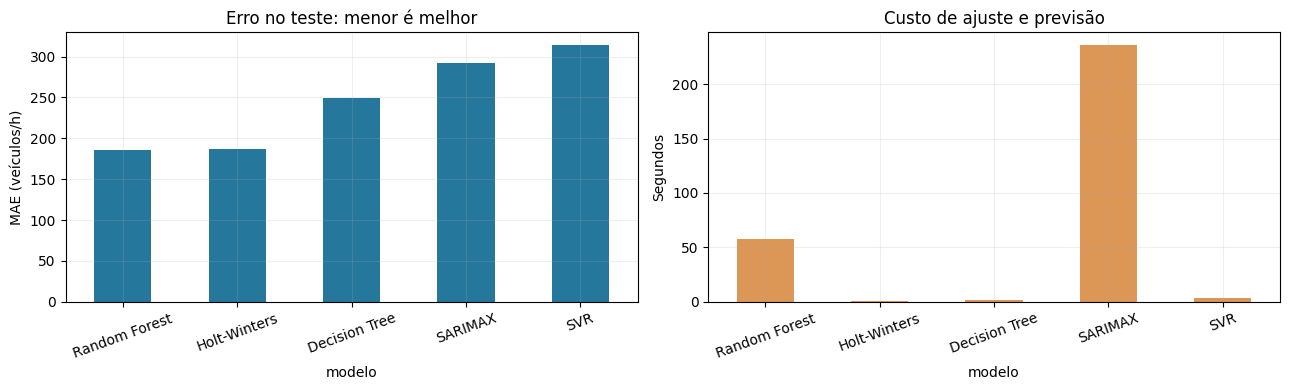

In [18]:
metric_rows = []
for name, group in predictions.groupby('modelo', sort=False):
    valid = group.dropna(subset=['valor_real'])
    metric_rows.append({'base':BASE_ID, 'modelo':name, 'mae':mean_absolute_error(valid.valor_real,valid.valor_previsto),
        'rmse':np.sqrt(mean_squared_error(valid.valor_real,valid.valor_previsto)),
        'vies':valid.residuo.mean(), 'n_previsoes':len(group), 'n_avaliadas':len(valid),
        'tempo_teste_s':runtime[name],
        'mae_validacao':search.loc[search.modelo.eq(name),'mae_validacao'].min()})
metrics = pd.DataFrame(metric_rows).sort_values('mae').reset_index(drop=True)
metrics['ranking'] = metrics.mae.rank(method='min').astype(int)
metrics.to_csv(RESULTS/'metrics/base_02_metrics.csv',index=False)
display(metrics.round(3))
fig,axes = plt.subplots(1,2,figsize=(13,4))
metrics.plot.bar(x='modelo',y='mae',ax=axes[0],legend=False,color='#25779c',rot=20)
axes[0].set_ylabel('MAE (veículos/h)'); axes[0].set_title('Erro no teste: menor é melhor')
metrics.plot.bar(x='modelo',y='tempo_teste_s',ax=axes[1],legend=False,color='#dc9656',rot=20)
axes[1].set_ylabel('Segundos'); axes[1].set_title('Custo de ajuste e previsão')
savefig('03_comparacao')

### 8.2 Previsões ao longo de uma semana

Sobrepor o início do teste para enxergar horários com erro ou mudança de padrão.

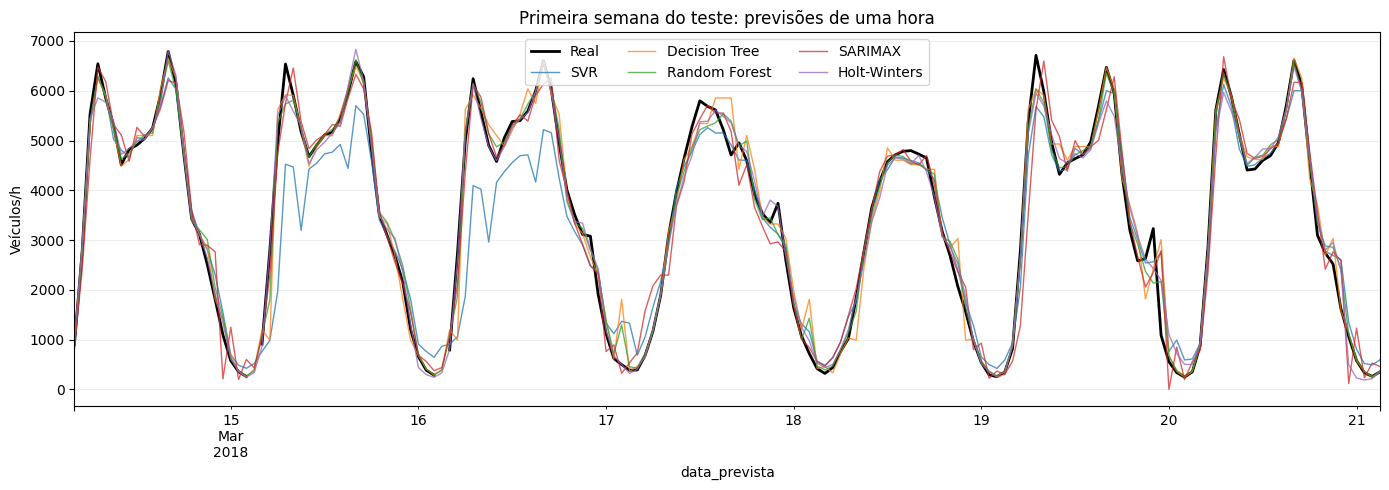

In [19]:
wide = predictions.pivot(index='data_prevista',columns='modelo',values='valor_previsto')
fig,ax = plt.subplots(figsize=(14,5))
y.loc[wide.index].iloc[:168].plot(ax=ax,color='black',lw=2,label='Real')
for name in MODEL_NAMES:
    wide[name].iloc[:168].plot(ax=ax,alpha=.75,lw=1,label=name)
ax.set_title('Primeira semana do teste: previsões de uma hora'); ax.set_ylabel('Veículos/h'); ax.legend(ncol=3)
savefig('04_previsoes')

### 8.3 Erros por horário, mês e referência semanal

A referência sazonal usa o tráfego observado 168 horas antes, avaliado apenas nas datas em comum.

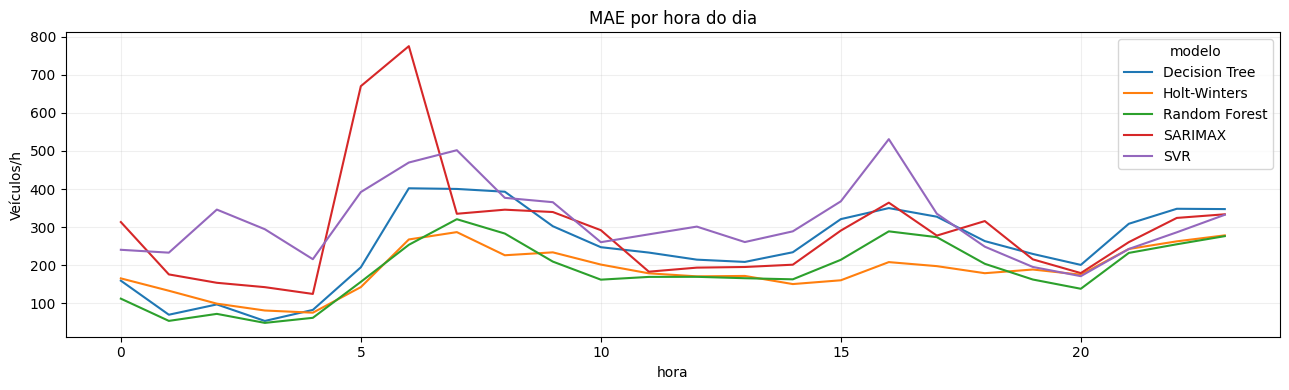

modelo,Decision Tree,Holt-Winters,Random Forest,SARIMAX,SVR
mes_teste,,,,,
2018-03,263.64,198.60,199.33,336.55,464.16
2018-04,305.95,220.38,236.29,317.11,334.15
2018-05,217.83,191.84,161.00,299.43,265.13
2018-06,223.93,148.66,158.96,269.29,245.07
2018-07,261.60,191.92,188.58,282.62,288.32
2018-08,193.44,150.34,143.46,261.97,397.70
2018-09,291.08,211.59,219.25,296.34,266.49


**Benchmark: comparação no subconjunto comum com lag de 168 h observado.**

,modelo,mae_mesmas_datas,n
3,Random Forest,183.77,4788
5,Holt-Winters,187.05,4788
2,Decision Tree,247.62,4788
4,SARIMAX,292.08,4788
0,Sazonal ingênuo (168 h),293.65,4788
1,SVR,312.21,4788


In [20]:
valid_errors = predictions[predictions.alvo_observado].copy()
valid_errors['erro_absoluto'] = valid_errors.residuo.abs()
valid_errors['hora'] = valid_errors.data_prevista.dt.hour
valid_errors['mes_teste'] = valid_errors.data_prevista.dt.to_period('M').astype(str)
hourly = valid_errors.pivot_table(index='hora',columns='modelo',values='erro_absoluto',aggfunc='mean')
monthly = valid_errors.pivot_table(index='mes_teste',columns='modelo',values='erro_absoluto',aggfunc='mean')
hourly.plot(title='MAE por hora do dia', ylabel='Veículos/h'); savefig('05_mae_hora')
display(monthly.round(2))
naive = y.shift(168).loc[wide.index]
mask = y.loc[wide.index].notna() & naive.notna()
baseline_rows = [{'modelo':'Sazonal ingênuo (168 h)', 'mae_mesmas_datas':mean_absolute_error(y.loc[wide.index][mask],naive[mask]),'n':int(mask.sum())}]
baseline_rows += [{'modelo':name,'mae_mesmas_datas':mean_absolute_error(y.loc[wide.index][mask],wide.loc[mask,name]),'n':int(mask.sum())} for name in MODEL_NAMES]
baseline_comparison = pd.DataFrame(baseline_rows).sort_values('mae_mesmas_datas')
display(Markdown('**Benchmark: comparação no subconjunto comum com lag de 168 h observado.**'))
display(baseline_comparison.round(2))

## 9. Resíduos, ACF e Ljung-Box

Os gráficos temporais preservam os intervalos sem alvo. Para ACF e Ljung-Box, usar o **maior trecho horário contínuo com alvos observados no teste**, comum aos cinco modelos; concatenar horas separadas por lacunas mudaria o significado das defasagens. O diagnóstico desse trecho não representa automaticamente todo o teste. Um p-valor abaixo de 0,05 indica evidência de autocorrelação residual; um valor maior não prova independência. O teste é descritivo para estes erros fora da amostra, com `model_df=0`, e envolve múltiplas defasagens.

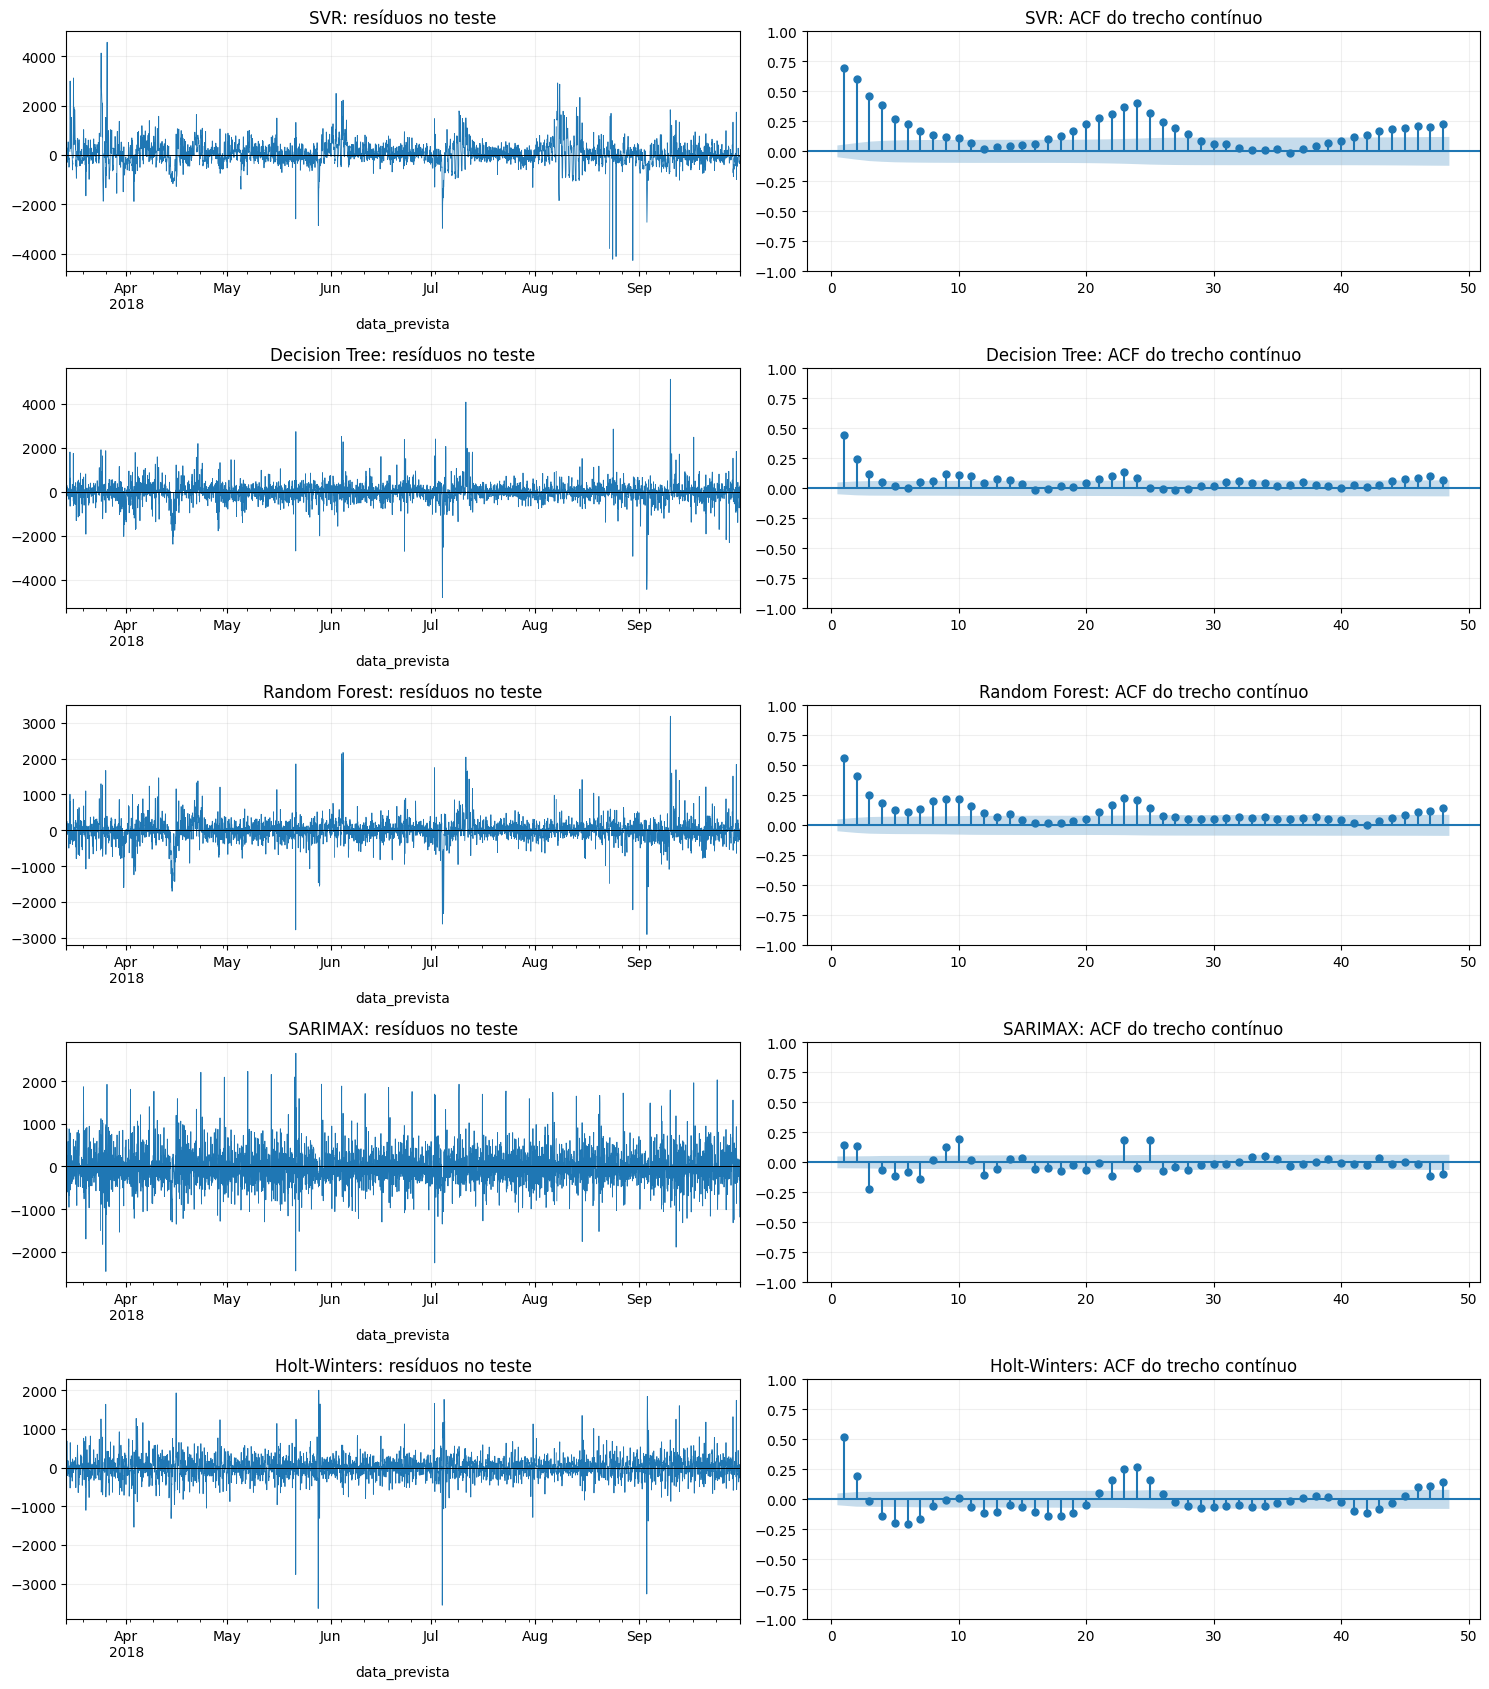

,base,modelo,lag,estatistica,p_valor,n_trecho,inicio,fim
0,base_02,SVR,24,3212.834288,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
1,base_02,SVR,48,4064.334290,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
2,base_02,SVR,168,5291.622384,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
3,base_02,Decision Tree,24,601.200649,1.329841e-111,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
4,base_02,Decision Tree,48,684.167889,2.175296e-113,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
5,base_02,Decision Tree,168,1027.854366,1.946669e-123,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
6,base_02,Random Forest,24,1549.048016,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
7,base_02,Random Forest,48,1774.982680,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
8,base_02,Random Forest,168,2368.429567,0.000000e+00,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
9,base_02,SARIMAX,24,425.253092,4.820081e-75,1588,2018-06-02 03:00:00,2018-08-07 06:00:00


In [21]:
observed_mask = y.loc[wide.index].notna()
runs = observed_mask.ne(observed_mask.shift()).cumsum()
longest = observed_mask[observed_mask].groupby(runs[observed_mask]).size().idxmax()
residual_dates = observed_mask.index[(runs==longest)&observed_mask]
assert len(residual_dates)>48
assert residual_dates.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
lb_rows = []
fig,axes = plt.subplots(5,2,figsize=(15,17))
for i,name in enumerate(MODEL_NAMES):
    res = y.loc[wide.index]-wide[name]
    res.plot(ax=axes[i,0],lw=.6,title=f'{name}: resíduos no teste')
    axes[i,0].axhline(0,color='black',lw=.7)
    segment = res.loc[residual_dates]
    lags = [lag for lag in [24,48,168] if lag < len(segment)//2]
    plot_acf(segment, lags=min(48,len(segment)//2-1), zero=False, ax=axes[i,1],title=f'{name}: ACF do trecho contínuo')
    lb = acorr_ljungbox(segment,lags=lags,return_df=True,model_df=0)
    for lag,row in lb.iterrows():
        lb_rows.append({'base':BASE_ID,'modelo':name,'lag':lag,'estatistica':row.lb_stat,
            'p_valor':row.lb_pvalue,'n_trecho':len(segment),'inicio':residual_dates[0],'fim':residual_dates[-1]})
savefig('06_residuos_acf')
ljung_box = pd.DataFrame(lb_rows)
display(ljung_box)
ljung_box.to_csv(RESULTS/'residuals/base_02_ljung_box.csv',index=False)
predictions[['base','modelo','data_prevista','valor_real','valor_previsto','residuo']].to_csv(
    RESULTS/'residuals/base_02_residuals.csv',index=False)

## 10. Importância das features e interpretação dos modelos

Permutation Importance mede o aumento de MAE após embaralhar uma feature. Usar o último fold de validação, com modelo ajustado antes desse fold, e as mesmas observações para os três modelos tabulares. Assim essa análise não usa o teste para selecionar variáveis. Features correlacionadas podem dividir importância; permutar horas quebra parte da dependência temporal. Os valores são diagnósticos, não efeitos causais.

Para SARIMAX, apresentar os coeficientes das exógenas no último ajuste de validação, com escala padronizada e alvo dividido por mil. Para Holt-Winters, mostrar nível, tendência e sazonalidade; ele não possui feature importance.

### 10.1 Permutation Importance nos três modelos tabulares

O cálculo usa o último fold de validação.

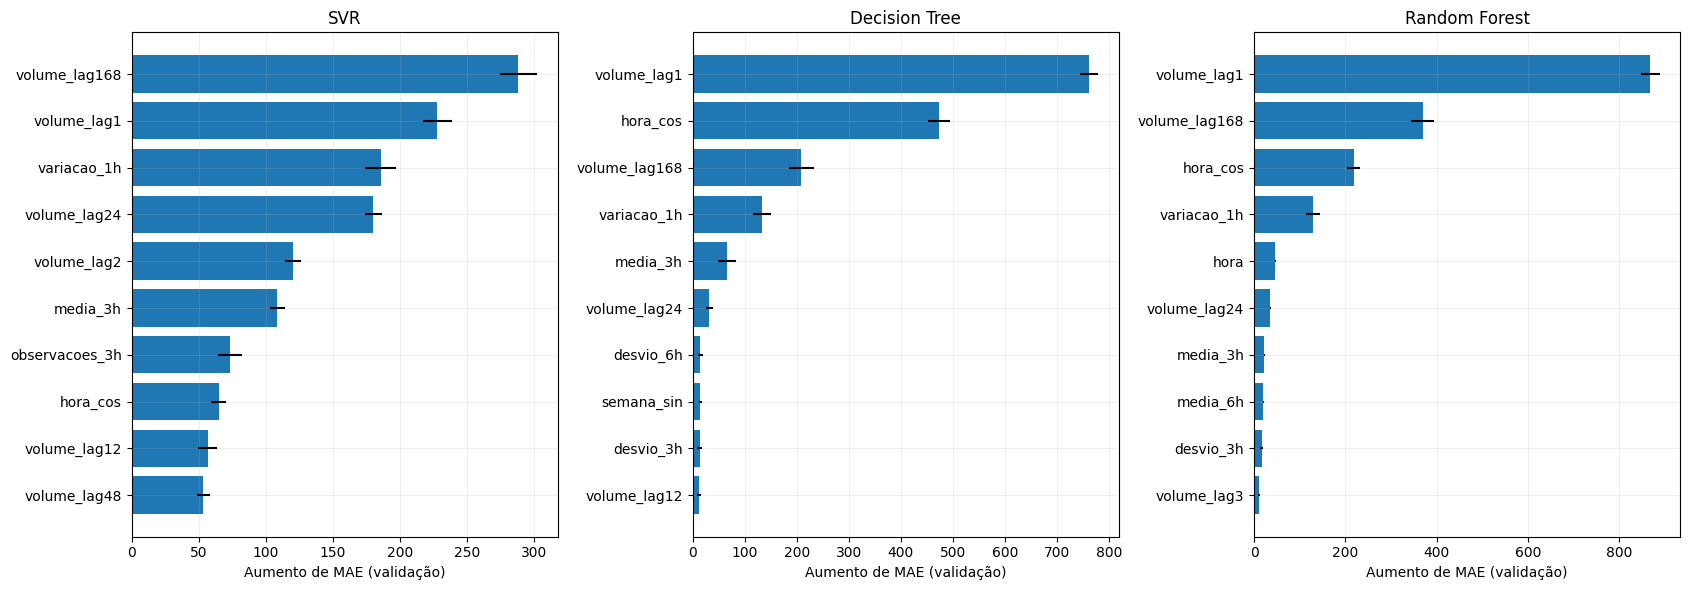

In [22]:
importance_rows = []
a,b = folds[-1]
mask = y.iloc[a:b].notna()
for name in ['SVR','Decision Tree','Random Forest']:
    _, model = forecast_block(name,selected[name],a,b,'interpretacao',True)
    imp = permutation_importance(model,X.iloc[a:b].loc[mask],y.iloc[a:b].loc[mask],
        scoring='neg_mean_absolute_error',n_repeats=3,random_state=RANDOM_STATE,n_jobs=1)
    for col,mean,std in zip(X.columns,imp.importances_mean,imp.importances_std):
        importance_rows.append({'base':BASE_ID,'modelo':name,'feature':col,
            'metodo':'permutation_validacao','aumento_mae':mean,'desvio':std})
importance = pd.DataFrame(importance_rows)
importance.to_csv(RESULTS/'feature_importance/base_02_feature_importance.csv',index=False)
fig,axes = plt.subplots(1,3,figsize=(17,6))
for ax,name in zip(axes,['SVR','Decision Tree','Random Forest']):
    top = importance[importance.modelo.eq(name)].nlargest(10,'aumento_mae').sort_values('aumento_mae')
    ax.barh(top.feature,top.aumento_mae,xerr=top.desvio)
    ax.set_title(name); ax.set_xlabel('Aumento de MAE (validação)')
savefig('07_importancia')

### 10.2 Coeficientes das exógenas no SARIMAX

In [23]:
_, sar_art = forecast_block('SARIMAX',selected['SARIMAX'],a,b,'interpretacao',True)
sar = sar_art[0]
coefficients = pd.DataFrame({'coeficiente':sar.params,'p_valor':sar.pvalues}).loc[EXOG_COLS]
display(coefficients)
coefficients.to_csv(RESULTS/'feature_importance/base_02_sarimax_coefficients.csv',index_label='feature')

,coeficiente,p_valor
hora_sin,-0.479296,1.553982e-04
hora_cos,-1.461301,2.748767e-33
semana_sin,0.050520,5.941339e-01
semana_cos,-0.311594,4.798840e-04
fim_de_semana,-0.104001,3.718730e-02
temp_lag1,0.023475,7.654714e-01
rain_1h_lag1,0.000000,NaN
snow_1h_lag1,0.000000,NaN
clouds_all_lag1,0.045366,6.868822e-03


### 10.3 Nível, tendência e sazonalidade em Holt-Winters

,nivel_final_veiculos,tendencia_final,periodo_sazonal,alpha,gamma
0,3343.638642,5.462912,168,0.4,0.2


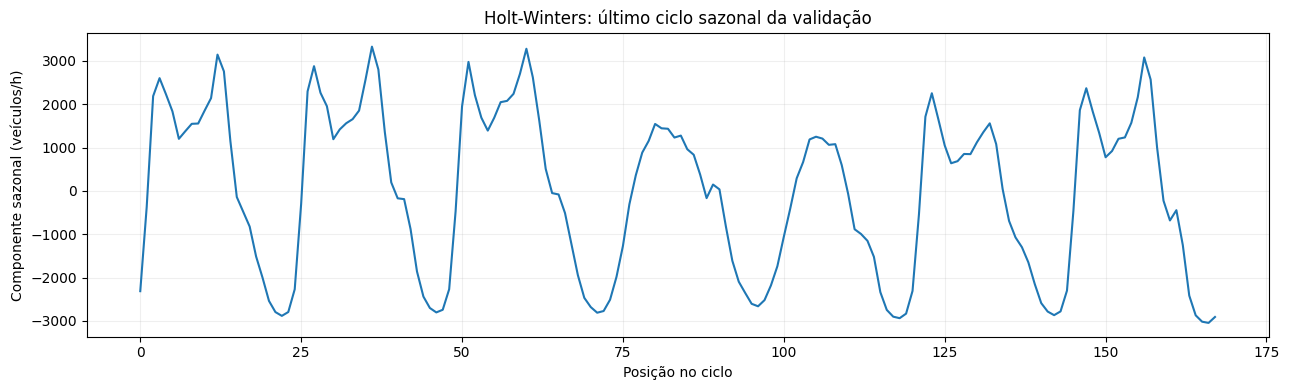

In [24]:
_, hw = forecast_block('Holt-Winters',selected['Holt-Winters'],a,b,'interpretacao',True)
display(pd.DataFrame([{'nivel_final_veiculos':float(hw.level.iloc[-1])*1000,
    'tendencia_final':float(hw.trend.iloc[-1])*1000 if hw.model.has_trend else 0,
    'periodo_sazonal':hw.model.seasonal_periods,'alpha':hw.params['smoothing_level'],
    'gamma':hw.params['smoothing_seasonal']}]))
pd.Series(np.asarray(hw.season[-hw.model.seasonal_periods:])*1000).plot(
    title='Holt-Winters: último ciclo sazonal da validação',ylabel='Componente sazonal (veículos/h)',xlabel='Posição no ciclo')
savefig('08_hw_sazonalidade')

## 11. Análise dos resultados e limites

O texto abaixo é calculado a partir das métricas, diagnósticos e importâncias desta execução. Ele distingue resultado observado de interpretação. Menor MAE identifica o vencedor neste recorte e protocolo; não estabelece superioridade universal do algoritmo.

### 11.1 Resultados e diagnóstico dos resíduos

In [25]:
best, runner = metrics.iloc[0], metrics.iloc[1]
relative = 100*(runner.mae-best.mae)/runner.mae
fastest = metrics.loc[metrics.tempo_teste_s.idxmin()]
lines = ['# Análise da Base 02', '',
    f'## Resultado principal', '',
    f'{best.modelo} obteve o menor MAE: {best.mae:.2f} veículos/h. '
    f'O segundo foi {runner.modelo}, com {runner.mae:.2f}. A redução relativa foi {relative:.1f}%. '
    f'A comparação usa {int(best.n_avaliadas)} horas com alvo observado entre {TEST_START} e {df.index[-1]}.', '',
    '## Leitura por modelo', '']
for row in metrics.itertuples():
    direction = 'subestimação média' if row.vies>0 else 'superestimação média'
    lines.append(f'- {row.modelo}: MAE {row.mae:.2f}, RMSE {row.rmse:.2f}, viés {row.vies:.2f} ({direction}), '
                 f'tempo de teste {row.tempo_teste_s:.1f} s. O MAE na validação foi {row.mae_validacao:.2f}.')
lines += ['', 'A diferença entre RMSE e MAE indica quanto erros grandes pesam no resultado. '
    'A diferença entre validação e teste também depende da época do ano e da dificuldade dos períodos; '
    'ela sozinha não comprova sobreajuste.', '', '## Estabilidade e custo', '',
    f'O menor tempo foi de {fastest.modelo}: {fastest.tempo_teste_s:.1f} s. '
    'Os tempos dependem da máquina e incluem os reajustes semanais; a busca não está incluída.']
monthly_wins = monthly.idxmin(axis=1).value_counts()
lines.append('Vitórias por mês do teste: '+', '.join(f'{name}: {n}' for name,n in monthly_wins.items())+'. Meses extremos podem ser parciais.')
worst_hour = hourly[best.modelo].idxmax()
lines.append(f'Para o vencedor, a hora de maior MAE foi {worst_hour}h ({hourly.loc[worst_hour,best.modelo]:.2f} veículos/h).')
lines += ['', '## Resíduos', '',
    f'ACF e Ljung-Box usam {len(residual_dates)} horas contínuas, de {residual_dates[0]} até {residual_dates[-1]}.']
for name in MODEL_NAMES:
    rows = ljung_box[ljung_box.modelo.eq(name)]
    rejected = rows.loc[rows.p_valor.lt(.05),'lag'].astype(str).tolist()
    lines.append(f'- {name}: '+('evidência de autocorrelação nas defasagens '+', '.join(rejected)+' horas.' if rejected else
                              'não houve rejeição a 5% nas defasagens examinadas; isso não prova independência.'))
lines += ['', '## O que os modelos aproveitaram', '']
for name in ['SVR','Decision Tree','Random Forest']:
    top = importance[importance.modelo.eq(name)].nlargest(3,'aumento_mae')
    lines.append(f'- {name}: maiores aumentos de MAE na permutação: '+', '.join(
        f'{r.feature} ({r.aumento_mae:.1f})' for r in top.itertuples())+'.')

## 12. Exportação e verificação final

As saídas podem ser lidas pelo notebook de comparação geral. `base_02.parquet` preserva a grade horária e as features não imputadas; a imputação pertence ao ajuste de cada modelo. Os CSVs de previsões mantêm horas sem alvo com resíduo vazio. O manifesto registra versões, fonte, recorte, janela, hiperparâmetros e política de avaliação.

In [27]:
logs = pd.DataFrame(fit_logs)
logs.to_csv(RESULTS/'tuning/base_02_fit_log.csv',index=False)
stl_summary.to_csv(RESULTS/'metrics/base_02_sazonalidade.csv',index=False)
monthly.to_csv(RESULTS/'metrics/base_02_mae_mensal.csv')
hourly.to_csv(RESULTS/'metrics/base_02_mae_horario.csv')
baseline_comparison.to_csv(RESULTS/'metrics/base_02_baseline.csv',index=False)
manifest = {'base':BASE_ID,'random_state':RANDOM_STATE,'frequencia':FREQ,'horizonte':HORIZON,
    'treino_proporcao_grade':TRAIN_RATIO,'teste_inicio':str(TEST_START),'teste_fim':str(df.index[-1]),
    'janela_ajuste_horas':TRAIN_WINDOW,'refit_horas':REFIT_HOURS,'validacao_folds':folds,
    'parametros':selected,'feature_cols':list(X.columns),'sarimax_exog':EXOG_COLS,
    'sha256_entrada':hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'versoes':{'python':platform.python_version(),'pandas':pd.__version__,'sklearn':sklearn.__version__,
               'statsmodels':statsmodels.__version__},
    'protocolo':'one-step, janela móvel, reajuste semanal, estados e lags atualizados a cada hora',
    'avaliacao':'somente alvos observados nas mesmas datas dos cinco modelos'}
(RESULTS/'tuning/base_02_manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
saved = pd.read_csv(RESULTS/'predictions/base_02_predictions.csv')
assert len(saved)==len(wide)*len(MODEL_NAMES)
assert saved.groupby('modelo').alvo_observado.sum().nunique()==1
assert np.isfinite(metrics[['mae','rmse','vies']].to_numpy()).all()
assert logs.treino_fim.lt(logs.previsao_inicio).all()
print('Concluído: cinco modelos, mesmas datas, análise e arquivos exportados.')
display(metrics[['ranking','modelo','mae','rmse','n_avaliadas']].round(2))

Concluído: cinco modelos, mesmas datas, análise e arquivos exportados.


,ranking,modelo,mae,rmse,n_avaliadas
0,1,Random Forest,185.62,319.87,4805
1,2,Holt-Winters,186.83,296.54,4805
2,3,Decision Tree,249.94,451.98,4805
3,4,SARIMAX,291.97,417.90,4805
4,5,SVR,314.04,494.93,4805
